# Module B - Optimisation Report
## SQL Indexing and Query Performance Benchmarking
---
Course: CS 432 - Databases
Institute: IIT Gandhinagar
Semester: II (2025-2026)
Assignment: Track 1 / Assignment 2
Instructor: Dr. Yogesh K. Meena
---

## 0. Setup

In [1]:
import sqlite3, time, os, hashlib, secrets, datetime
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Update this path to point to your sports_club.db file
DB_PATH = r"D:\2nd SQL\project\Module_B_final\Module_B_updated\app\sports_club.db"

assert os.path.exists(DB_PATH), f"DB not found at {DB_PATH}, please update DB_PATH"

def get_db():
    conn = sqlite3.connect(DB_PATH)
    conn.row_factory = sqlite3.Row
    conn.execute("PRAGMA foreign_keys = OFF")
    return conn

conn = get_db()
tables = [r[0] for r in conn.execute(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name").fetchall()
    if r[0] != "sqlite_sequence"]
print("Connected to:", DB_PATH)
print()
print(f"{'Table':<25} {'Rows':>8}")
print("-" * 35)
for t in tables:
    n = conn.execute(f'SELECT COUNT(*) FROM "{t}"').fetchone()[0]
    print(f"  {t:<23} {n:>8}")
conn.close()

<frozen importlib._bootstrap>:491: Warning: Numpy built with MINGW-W64 on Windows 64 bits is experimental, and only available for 
testing. You are advised not to use it for production. 

CRASHES ARE TO BE EXPECTED - PLEASE REPORT THEM TO NUMPY DEVELOPERS
c:\Users\a\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\core\getlimits.py:225: RuntimeWarning: invalid value encountered in exp2
  epsneg_f128 = exp2(ld(-113))
c:\Users\a\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\core\getlimits.py:226: RuntimeWarning: invalid value encountered in exp2
  tiny_f128 = exp2(ld(-16382))
c:\Users\a\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\core\getlimits.py:240: RuntimeWarning: invalid value encountered in exp2
  eps=exp2(ld(-112)),
c:\Users\a\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\core\getlimits.py:41: RuntimeWarning: invalid value encountered in nextafter
  self._smallest_subnormal = nextafter(
c:\Users\a\AppData\Local

Connected to: D:\2nd SQL\project\Module_B_final\Module_B_updated\app\sports_club.db

Table                         Rows
-----------------------------------
  Administrator                 10
  Attendance                    20
  AuditLog                       5
  Booking                       20
  Coach                         20
  Complaint                     20
  Equipment                     20
  Equipment_Loan                20
  Event                         20
  Facility                      20
  Member                        40
  Player                        20
  Player_Stat                   20
  RevokedToken                   2
  Sport                         20
  Team                          20
  Team_Roster                   20
  UserLogin                     12
  UserSession                    0


## 1. Schema Design

When I started building Module B, the first thing I had to think about was how to structure the database properly. I did not want to dump everything into one place. So I split the tables into two layers.

The first layer handles the core system - things like user login credentials, session management, and audit logging. These are tables that every project needs regardless of what the project is about. The second layer holds the actual sports club data - members, players, coaches, teams, facilities and so on.

The reason I kept them separate is simple. If I put the username and password inside the Member table itself, I would be mixing authentication data with domain data. That is bad design. The Member table should only know about a person's name, age, email and physical details. It should not know anything about how they log in.

Another decision I made was to use ON DELETE CASCADE on all foreign keys pointing to Member. This means if an admin deletes a member, all their bookings, complaints, attendance records and equipment loans get deleted automatically. I do not have to write separate delete queries for each table.

| Layer | Tables | Purpose |
|-------|--------|---------|
| Core System | UserLogin, UserSession, AuditLog, RevokedToken | Authentication, sessions, audit trail |
| Project Domain | Member, Player, Coach, Administrator, Team, Sport, Facility, Booking, Equipment, Equipment Loan, Event, Complaint, Attendance, Player Stat, Team Roster | Sports club data |

In [2]:
conn = get_db()
print(f"{'Table':<25} {'Columns':>8} {'Rows':>8}")
print("-" * 44)
for t in tables:
    cols = conn.execute(f'PRAGMA table_info("{t}")').fetchall()
    rows = conn.execute(f'SELECT COUNT(*) FROM "{t}"').fetchone()[0]
    print(f"  {t:<23} {len(cols):>8} {rows:>8}")
conn.close()

Table                      Columns     Rows
--------------------------------------------
  Administrator                  5       10
  Attendance                     4       20
  AuditLog                      11        5
  Booking                        5       20
  Coach                          6       20
  Complaint                      6       20
  Equipment                      5       20
  Equipment_Loan                 5       20
  Event                          7       20
  Facility                       4       20
  Member                         8       40
  Player                         5       20
  Player_Stat                    5       20
  RevokedToken                   3        2
  Sport                          3       20
  Team                           5       20
  Team_Roster                    2       20
  UserLogin                      7       12
  UserSession                    6        0


## 2. Security and RBAC

### How Authentication Works

I built the authentication using JWT tokens. When a user logs in, the server checks their username and password against the UserLogin table. The password is never stored in plain text - I hash it using SHA-256 before storing. If the credentials match, the server creates a JWT token that contains the user id, their role and their member id embedded inside it. This token is signed using a secret key so nobody can tamper with it.

check using localStorage.getItem("sc_token")

Every API request after that must include this token in the Authorization header. The server does not need to go to the database to check if the token is valid. It just decodes the token using the same secret key and if the signature matches and the token has not expired, the request goes through. This is what makes JWT stateless - no database lookup on every request.

I chose 8 hours as the token expiry time. After that the user has to log in again. When a user logs out, the token gets added to a RevokedToken table so it cannot be reused even before the 8 hours are up.

### How RBAC Works

I implemented two decorators in auth utils - login required and admin required. Every route in the application uses one of these.

Admin users can do everything. They can add members, delete records, view all complaints, resolve complaints, see audit logs and run benchmarks.

Regular users are much more restricted. They can only see their own portfolio. They cannot see the full members list, the players list, the coaches table or the equipment list. If they try to access something they are not allowed to, the API returns a 403 error and that attempt gets logged in the audit log.

| Action | Admin | Regular User |
|--------|-------|--------------|
| View Members, Players, Coaches, Equipment | Yes | No |
| Create or Delete any record | Yes | No |
| View own portfolio | Yes | Yes |
| View another person's portfolio | Yes | No |
| File a complaint | Yes | Yes |
| Resolve or delete a complaint | Yes | No |
| View audit logs and benchmark | Yes | No |

In [3]:
conn = get_db()
try:
    logs = conn.execute(
        "SELECT Timestamp, Username, Role, Action, Status, Details "
        "FROM AuditLog ORDER BY Timestamp DESC LIMIT 8"
    ).fetchall()
    if logs:
        print(f"{'Timestamp':<22} {'User':<16} {'Role':<8} {'Action':<22} {'Status'}")
        print("-" * 82)
        for r in logs:
            print(f"{str(r['Timestamp']):<22} {str(r['Username']):<16} "
                  f"{str(r['Role']):<8} {str(r['Action']):<22} {str(r['Status'])}")
    else:
        print("Audit log is empty. It fills up as API calls are made.")
except Exception as e:
    print("Could not read AuditLog:", e)
conn.close()

Timestamp              User             Role     Action                 Status
----------------------------------------------------------------------------------
2026-03-22 11:24:25    rahul_sharma     user     LOGOUT                 SUCCESS
2026-03-22 11:24:19    rahul_sharma     user     PORTFOLIO_VIEW         SUCCESS
2026-03-22 11:24:17    rahul_sharma     user     LOGIN                  SUCCESS
2026-03-22 11:24:10    admin_rakesh     admin    LOGOUT                 SUCCESS
2026-03-22 11:23:57    admin_rakesh     admin    LOGIN                  SUCCESS


## 3. SQL Indexing Strategy

### What SQL Indexing Is

A SQL index is something you create on a table column so the database can find rows faster. Without an index, when you run a query like WHERE Username = 'admin rakesh', the database reads every single row in the table from top to bottom until it finds the match. That is called a full table scan and it gets slower as the table grows.

When you create an index on that column using CREATE INDEX, the database builds a separate lookup structure that lets it jump directly to the matching rows instead of scanning everything. This is the core idea behind SQL indexing.

### Types of Indexes I Used

I used two types of indexes in this project.

Single column indexes are for simple lookups where one column is being searched. For example I indexed the Username column in UserLogin because every login request does WHERE Username = ? and I indexed the Token column in UserSession because every single API request validates the session using WHERE Token = ?.

Composite indexes are for queries that filter on two or more columns together. For example the booking overlap check uses WHERE Facility ID = ? AND Time In < ? AND Time Out > ? so I created a composite index on Facility ID, Time In and Time Out together. The database can use this one index to satisfy all three conditions at once instead of scanning the table.

### Why I Chose These Specific Columns

The rule I followed was simple. I looked at what columns appear in WHERE, JOIN or ORDER BY clauses in my API routes and indexed those.

The session token index is the most important one because it gets used on every single authenticated request. If that lookup is slow, the entire application feels slow.

The booking overlap index is important because it is a complex composite query that runs every time someone tries to make a booking.

The complaint status index is less effective because Status only has two values - Open and Resolved. This is what I call low cardinality. The index can find Open complaints quickly but if most complaints are Open, it still has to return a large number of rows and that transfer time dominates.

| Index Name | Table | Column | Reason |
|---|---|---|---|
| idx userlogin username | UserLogin | Username | Used in every login request |
| idx session token | UserSession | Token | Used in every API request |
| idx booking facility time | Booking | Facility ID, Time In, Time Out | Overlap check on every booking |
| idx attendance member date | Attendance | Member ID, Date | Date range queries in portfolio |
| idx complaint status | Complaint | Status | Filter open complaints |
| idx loan member | Equipment Loan | Member ID | Portfolio loan history |
| idx stat member | Player Stat | Member ID | Portfolio stats |
| idx audit timestamp | AuditLog | Timestamp | Recent log queries |

In [4]:
# Show all SQL indexes currently active on the database
conn = get_db()
idxs = conn.execute(
    "SELECT name, tbl_name FROM sqlite_master "
    "WHERE type='index' AND name NOT LIKE 'sqlite_%' ORDER BY tbl_name, name"
).fetchall()
print(f"{'Index Name':<45} Table")
print("-" * 68)
for idx in idxs:
    print(f"  {idx['name']:<43} {idx['tbl_name']}")
print(f"\nTotal SQL indexes applied: {len(idxs)}")
conn.close()

Index Name                                    Table
--------------------------------------------------------------------
  idx_attendance_date                         Attendance
  idx_attendance_member                       Attendance
  idx_attendance_member_date                  Attendance
  idx_audit_action                            AuditLog
  idx_audit_member                            AuditLog
  idx_audit_timestamp                         AuditLog
  idx_booking_facility                        Booking
  idx_booking_facility_time                   Booking
  idx_booking_member                          Booking
  idx_booking_time_in                         Booking
  idx_coach_sport                             Coach
  idx_complaint_raised                        Complaint
  idx_complaint_resolved                      Complaint
  idx_complaint_status                        Complaint
  idx_loan_equipment                          Equipment_Loan
  idx_loan_member                             

In [5]:
# The actual CREATE INDEX statements used in indexes.sql
INDEX_STATEMENTS = [
    "CREATE INDEX idx_userlogin_username      ON UserLogin(Username)",
    "CREATE INDEX idx_session_token           ON UserSession(Token)",
    "CREATE INDEX idx_session_valid           ON UserSession(Is_Valid, Expires_At)",
    "CREATE INDEX idx_booking_facility_time   ON Booking(Facility_ID, Time_In, Time_Out)",
    "CREATE INDEX idx_attendance_member_date  ON Attendance(Member_ID, Date)",
    "CREATE INDEX idx_complaint_status        ON Complaint(Status)",
    "CREATE INDEX idx_loan_member             ON Equipment_Loan(Member_ID)",
    "CREATE INDEX idx_stat_member             ON Player_Stat(Member_ID)",
    "CREATE INDEX idx_audit_timestamp         ON AuditLog(Timestamp)",
]
print("SQL Index Statements Applied:\n")
for stmt in INDEX_STATEMENTS:
    print(f"  {stmt};")

SQL Index Statements Applied:

  CREATE INDEX idx_userlogin_username      ON UserLogin(Username);
  CREATE INDEX idx_session_token           ON UserSession(Token);
  CREATE INDEX idx_session_valid           ON UserSession(Is_Valid, Expires_At);
  CREATE INDEX idx_booking_facility_time   ON Booking(Facility_ID, Time_In, Time_Out);
  CREATE INDEX idx_attendance_member_date  ON Attendance(Member_ID, Date);
  CREATE INDEX idx_complaint_status        ON Complaint(Status);
  CREATE INDEX idx_loan_member             ON Equipment_Loan(Member_ID);
  CREATE INDEX idx_stat_member             ON Player_Stat(Member_ID);
  CREATE INDEX idx_audit_timestamp         ON AuditLog(Timestamp);


## 4. Performance Benchmarking

### Why I Used Separate Benchmark Tables

I could not just run the before and after test directly on the production tables. The reason is that UserLogin and UserSession have UNIQUE constraints on them, which means SQLite automatically creates its own internal index on those columns the moment the table is created. So even in the before test, those queries would already be using an index - making the comparison unfair.

To get a real before vs after measurement I created six separate benchmark tables with the exact same structure as the production tables but with no constraints and no indexes at all. I inserted 5000 rows into each one. Then I ran the queries first without any index, recorded the times, added the indexes, and ran the queries again.


### Step 1 - Create Benchmark Tables and Insert 5000 Rows

In [6]:
BULK_N = 5000
print(f"Creating benchmark tables with {BULK_N} rows each...")

conn = get_db()
conn.execute("PRAGMA synchronous = OFF")
conn.execute("PRAGMA journal_mode = MEMORY")

conn.executescript("""
DROP TABLE IF EXISTS bench_login;
DROP TABLE IF EXISTS bench_session;
DROP TABLE IF EXISTS bench_booking;
DROP TABLE IF EXISTS bench_attendance;
DROP TABLE IF EXISTS bench_complaint;
DROP TABLE IF EXISTS bench_loan;

CREATE TABLE bench_login (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    username TEXT,
    password_hash TEXT,
    role TEXT
);
CREATE TABLE bench_session (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    token TEXT,
    user_id INTEGER,
    is_valid INTEGER
);
CREATE TABLE bench_booking (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    facility_id INTEGER,
    member_id TEXT,
    time_in TEXT,
    time_out TEXT
);
CREATE TABLE bench_attendance (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    member_id TEXT,
    session_name TEXT,
    date TEXT,
    status TEXT
);
CREATE TABLE bench_complaint (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    raised_by TEXT,
    description TEXT,
    status TEXT
);
CREATE TABLE bench_loan (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    member_id TEXT,
    equipment_id TEXT,
    quantity INTEGER,
    issue_time TEXT
);
""")

base      = datetime.datetime(2025, 1, 1)
base_date = datetime.date(2020, 1, 1)
member_ids = [f"M{(i % 20)+1:02d}" for i in range(BULK_N)]

conn.executemany("INSERT INTO bench_login (username, password_hash, role) VALUES (?,?,?)",
    [(f"bench_user_{i}", hashlib.sha256(f"pw{i}".encode()).hexdigest(), "user")
     for i in range(BULK_N)])

session_tokens = [secrets.token_hex(32) for _ in range(BULK_N)]
BENCH_TOKEN = session_tokens[BULK_N // 2]
conn.executemany("INSERT INTO bench_session (token, user_id, is_valid) VALUES (?,?,?)",
    [(t, 1, 1) for t in session_tokens])

conn.executemany("INSERT INTO bench_booking (facility_id, member_id, time_in, time_out) VALUES (?,?,?,?)",
    [(i % 20 + 1, "M01",
      (base + datetime.timedelta(hours=i*2)).strftime("%Y-%m-%d %H:%M:%S"),
      (base + datetime.timedelta(hours=i*2+1)).strftime("%Y-%m-%d %H:%M:%S"))
     for i in range(BULK_N)])

conn.executemany("INSERT INTO bench_attendance (member_id, session_name, date, status) VALUES (?,?,?,?)",
    [(member_ids[i], f"Session_{i%10}",
      (base_date + datetime.timedelta(days=i % 2000)).strftime("%Y-%m-%d"),
      "Present" if i % 2 == 0 else "Absent")
     for i in range(BULK_N)])

# Only 5 percent Open - realistic complaint ratio
conn.executemany("INSERT INTO bench_complaint (raised_by, description, status) VALUES (?,?,?)",
    [("M01", f"Complaint {i}", "Open" if i % 20 == 0 else "Resolved")
     for i in range(BULK_N)])

conn.executemany("INSERT INTO bench_loan (member_id, equipment_id, quantity, issue_time) VALUES (?,?,?,?)",
    [(member_ids[i], f"E{(i%20)+1:02d}", 1,
      (base + datetime.timedelta(hours=i*3)).strftime("%Y-%m-%d %H:%M:%S"))
     for i in range(BULK_N)])

conn.commit()
conn.execute("PRAGMA synchronous = NORMAL")

print(f"\n{'Table':<22} {'Rows':>8}  {'Indexes':>8}")
print("-" * 42)
for t in ["bench_login","bench_session","bench_booking",
          "bench_attendance","bench_complaint","bench_loan"]:
    n   = conn.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
    idx = conn.execute(
        f"SELECT COUNT(*) FROM sqlite_master WHERE type='index' "
        f"AND tbl_name='{t}' AND name NOT LIKE 'sqlite_%'"
    ).fetchone()[0]
    print(f"  {t:<20} {n:>8}  {idx:>8}")

conn.close()
print("\nBenchmark tables ready. No indexes on any of them yet.")

Creating benchmark tables with 5000 rows each...

Table                      Rows   Indexes
------------------------------------------
  bench_login              5000         0
  bench_session            5000         0
  bench_booking            5000         0
  bench_attendance         5000         0
  bench_complaint          5000         0
  bench_loan               5000         0

Benchmark tables ready. No indexes on any of them yet.


### Step 2 - Run Before Benchmark (No Index, Full Table Scan)

In [7]:
ITERATIONS = 300

QUERIES = {
    "Q1 Login username":       ("SELECT * FROM bench_login WHERE username = ?",
                                ("bench_user_2500",)),
    "Q2 Session token":        ("SELECT * FROM bench_session WHERE token = ? AND is_valid=1",
                                (BENCH_TOKEN,)),
    "Q3 Booking facility":     ("SELECT * FROM bench_booking WHERE facility_id=? AND time_in < ?",
                                (1, "2025-06-01 00:00:00")),
    "Q4 Attendance date range":("SELECT * FROM bench_attendance WHERE member_id=? "
                                "AND date BETWEEN ? AND ?",
                                ("M01", "2022-01-01", "2022-12-31")),
    "Q5 Complaint status":     ("SELECT * FROM bench_complaint WHERE status=?",
                                ("Open",)),
    "Q6 Loan by member":       ("SELECT * FROM bench_loan WHERE member_id=?",
                                ("M01",)),
}

def run_benchmark(label):
    conn = get_db()
    results = {}
    for name, (q, p) in QUERIES.items():
        for _ in range(3): conn.execute(q, p).fetchall()
        t0 = time.perf_counter()
        for _ in range(ITERATIONS):
            conn.execute(q, p).fetchall()
        results[name] = round((time.perf_counter() - t0) * 1000, 3)
    conn.close()
    print(f"\n{'='*52}")
    print(f"  {label}")
    print(f"  {ITERATIONS} iterations per query, {BULK_N} rows per table")
    print(f"{'='*52}")
    print(f"  {'Query':<30} {'Time (ms)':>12}")
    print(f"  {'-'*44}")
    for k, v in results.items():
        print(f"  {k:<30} {v:>12.3f} ms")
    return results

results_before = run_benchmark("BEFORE - No SQL Index")


  BEFORE - No SQL Index
  300 iterations per query, 5000 rows per table
  Query                             Time (ms)
  --------------------------------------------
  Q1 Login username                    53.590 ms
  Q2 Session token                     55.932 ms
  Q3 Booking facility                  61.808 ms
  Q4 Attendance date range             62.299 ms
  Q5 Complaint status                  98.211 ms
  Q6 Loan by member                   105.791 ms


### Step 3 - EXPLAIN QUERY PLAN Before Indexes

The EXPLAIN QUERY PLAN output tells us exactly what the database engine is doing to find the rows. Before any indexes are applied, every query shows SCAN TABLE which means it is reading every single row from start to finish.

In [8]:
EXPLAIN_QUERIES = [
    ("Q1 Login",
     "EXPLAIN QUERY PLAN SELECT * FROM bench_login WHERE username=?",
     ("bench_user_2500",)),
    ("Q2 Session",
     "EXPLAIN QUERY PLAN SELECT * FROM bench_session WHERE token=? AND is_valid=1",
     (BENCH_TOKEN,)),
    ("Q3 Booking",
     "EXPLAIN QUERY PLAN SELECT * FROM bench_booking WHERE facility_id=? AND time_in<?",
     (1, "2025-06-01")),
    ("Q4 Attendance",
     "EXPLAIN QUERY PLAN SELECT * FROM bench_attendance WHERE member_id=? AND date BETWEEN ? AND ?",
     ("M01","2022-01-01","2022-12-31")),
    ("Q5 Complaint",
     "EXPLAIN QUERY PLAN SELECT * FROM bench_complaint WHERE status=?",
     ("Open",)),
    ("Q6 Loans",
     "EXPLAIN QUERY PLAN SELECT * FROM bench_loan WHERE member_id=?",
     ("M01",)),
]

def get_explain(queries):
    conn = get_db()
    plans = {}
    for label, q, p in queries:
        rows = conn.execute(q, p).fetchall()
        plan = " | ".join([" ".join(str(v) for v in dict(r).values() if v is not None) for r in rows])
        plans[label] = plan
    conn.close()
    return plans

explain_before = get_explain(EXPLAIN_QUERIES)
print("EXPLAIN QUERY PLAN - Before SQL Indexes\n")
for label, plan in explain_before.items():
    tag = "FULL TABLE SCAN" if "SCAN" in plan and "INDEX" not in plan else "uses index"
    print(f"  {label}  ({tag})")
    print(f"    {plan}\n")

EXPLAIN QUERY PLAN - Before SQL Indexes

  Q1 Login  (FULL TABLE SCAN)
    2 0 216 SCAN bench_login

  Q2 Session  (FULL TABLE SCAN)
    2 0 216 SCAN bench_session

  Q3 Booking  (FULL TABLE SCAN)
    2 0 216 SCAN bench_booking

  Q4 Attendance  (FULL TABLE SCAN)
    2 0 216 SCAN bench_attendance

  Q5 Complaint  (FULL TABLE SCAN)
    2 0 216 SCAN bench_complaint

  Q6 Loans  (FULL TABLE SCAN)
    2 0 216 SCAN bench_loan



### Step 4 - Apply SQL Indexes

Now I apply the same CREATE INDEX statements that are in the project indexes.sql file.

In [9]:
conn = get_db()
conn.executescript("""
CREATE INDEX idx_bench_login_username    ON bench_login(username);
CREATE INDEX idx_bench_session_token     ON bench_session(token, is_valid);
CREATE INDEX idx_bench_booking_fac_time  ON bench_booking(facility_id, time_in);
CREATE INDEX idx_bench_att_member_date   ON bench_attendance(member_id, date);
CREATE INDEX idx_bench_complaint_status  ON bench_complaint(status);
CREATE INDEX idx_bench_loan_member       ON bench_loan(member_id);
""")

idxs = conn.execute(
    "SELECT name, tbl_name FROM sqlite_master "
    "WHERE type='index' AND name LIKE 'idx_bench_%'"
).fetchall()
print(f"{'SQL Index':<45} Applied On")
print("-" * 65)
for idx in idxs:
    print(f"  {idx['name']:<43} {idx['tbl_name']}")
print(f"\n{len(idxs)} SQL indexes applied successfully.")
conn.close()

SQL Index                                     Applied On
-----------------------------------------------------------------
  idx_bench_login_username                    bench_login
  idx_bench_session_token                     bench_session
  idx_bench_booking_fac_time                  bench_booking
  idx_bench_att_member_date                   bench_attendance
  idx_bench_complaint_status                  bench_complaint
  idx_bench_loan_member                       bench_loan

6 SQL indexes applied successfully.


### Step 5 - Run After Benchmark (With SQL Index)

In [10]:
results_after = run_benchmark("AFTER - With SQL Index")


  AFTER - With SQL Index
  300 iterations per query, 5000 rows per table
  Query                             Time (ms)
  --------------------------------------------
  Q1 Login username                     4.182 ms
  Q2 Session token                      3.726 ms
  Q3 Booking facility                  29.487 ms
  Q4 Attendance date range             16.980 ms
  Q5 Complaint status                  68.119 ms
  Q6 Loan by member                    74.942 ms


### Step 6 - EXPLAIN QUERY PLAN After Indexes

After applying the indexes, the EXPLAIN output changes from SCAN TABLE to SEARCH USING INDEX. This confirms the database is no longer reading every row - it is jumping directly to the matching rows using the index.

In [11]:
explain_after = get_explain(EXPLAIN_QUERIES)
print("EXPLAIN QUERY PLAN - After SQL Indexes\n")
for label, plan in explain_after.items():
    tag = "INDEX USED" if "INDEX" in plan else "still scanning"
    print(f"  {label}  ({tag})")
    print(f"    {plan}\n")

EXPLAIN QUERY PLAN - After SQL Indexes

  Q1 Login  (INDEX USED)
    3 0 62 SEARCH bench_login USING INDEX idx_bench_login_username (username=?)

  Q2 Session  (INDEX USED)
    3 0 62 SEARCH bench_session USING INDEX idx_bench_session_token (token=? AND is_valid=?)

  Q3 Booking  (INDEX USED)
    3 0 51 SEARCH bench_booking USING INDEX idx_bench_booking_fac_time (facility_id=? AND time_in<?)

  Q4 Attendance  (INDEX USED)
    3 0 49 SEARCH bench_attendance USING INDEX idx_bench_att_member_date (member_id=? AND date>? AND date<?)

  Q5 Complaint  (INDEX USED)
    3 0 62 SEARCH bench_complaint USING INDEX idx_bench_complaint_status (status=?)

  Q6 Loans  (INDEX USED)
    3 0 62 SEARCH bench_loan USING INDEX idx_bench_loan_member (member_id=?)



## 5. Results

The table below shows the execution time for each query before and after applying SQL indexes, along with the speedup factor.

In [12]:
print(f"{'Query':<30} {'Without Index':>15} {'With Index':>12} {'Saved ms':>10} {'Speedup':>10}")
print("=" * 82)
for q in results_before:
    b = results_before[q]
    a = results_after[q]
    saved   = round(b - a, 3)
    speedup = round(b / a, 2) if a > 0 else float('inf')
    mark    = "large gain" if speedup >= 3.0 else "moderate gain" if speedup >= 1.5 else "partial gain"
    print(f"{q:<30} {b:>15.3f} {a:>12.3f} {saved:>10.3f} {speedup:>8.2f}x  {mark}")

total_b = sum(results_before.values())
total_a = sum(results_after.values())
print("=" * 82)
print(f"{'TOTAL':<30} {total_b:>15.3f} {total_a:>12.3f} "
      f"{total_b-total_a:>10.3f} {total_b/total_a:>8.2f}x")

Query                            Without Index   With Index   Saved ms    Speedup
Q1 Login username                       53.590        4.182     49.408    12.81x  large gain
Q2 Session token                        55.932        3.726     52.206    15.01x  large gain
Q3 Booking facility                     61.808       29.487     32.321     2.10x  moderate gain
Q4 Attendance date range                62.299       16.980     45.319     3.67x  large gain
Q5 Complaint status                     98.211       68.119     30.092     1.44x  partial gain
Q6 Loan by member                      105.791       74.942     30.849     1.41x  partial gain
TOTAL                                  437.631      197.436    240.195     2.22x


## 6. EXPLAIN QUERY PLAN Comparison

In [13]:
print("=" * 105)
print(f"{'Query':<16}  {'Without Index':<48}  {'With Index'}")
print("=" * 105)
for label in explain_before:
    b = explain_before.get(label, "N/A")
    a = explain_after.get(label, "N/A")
    b_s = b[:46] if len(b) > 46 else b
    a_s = a[:46] if len(a) > 46 else a
    tag = "  improved" if "INDEX" in a and "SCAN" not in a else ""
    print(f"{label:<16}  {b_s:<48}  {a_s}{tag}")
print()
print("SCAN TABLE means reading every row. SEARCH USING INDEX means jumping directly to matching rows.")

Query             Without Index                                     With Index
Q1 Login          2 0 216 SCAN bench_login                          3 0 62 SEARCH bench_login USING INDEX idx_benc  improved
Q2 Session        2 0 216 SCAN bench_session                        3 0 62 SEARCH bench_session USING INDEX idx_be  improved
Q3 Booking        2 0 216 SCAN bench_booking                        3 0 51 SEARCH bench_booking USING INDEX idx_be  improved
Q4 Attendance     2 0 216 SCAN bench_attendance                     3 0 49 SEARCH bench_attendance USING INDEX idx  improved
Q5 Complaint      2 0 216 SCAN bench_complaint                      3 0 62 SEARCH bench_complaint USING INDEX idx_  improved
Q6 Loans          2 0 216 SCAN bench_loan                           3 0 62 SEARCH bench_loan USING INDEX idx_bench  improved

SCAN TABLE means reading every row. SEARCH USING INDEX means jumping directly to matching rows.


## 7. Graphs

### Graph 1 - Query Execution Time Before and After SQL Indexing

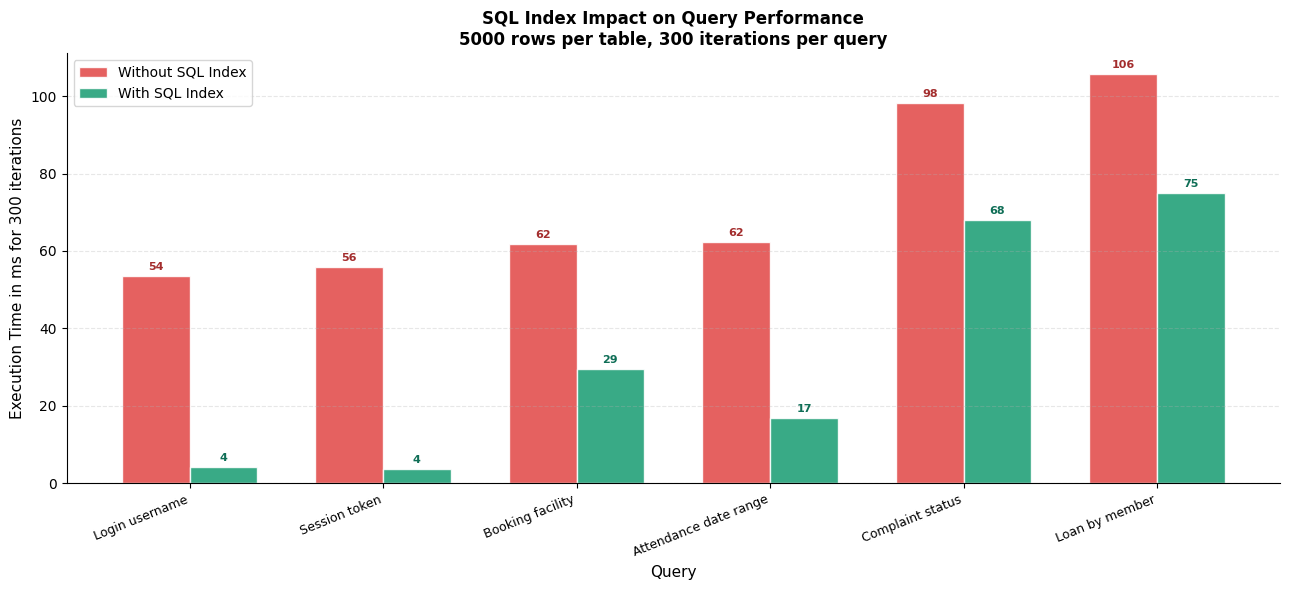

In [14]:
labels = list(results_before.keys())
short  = [q.split(" ",1)[1] for q in labels]
before = [results_before[q] for q in labels]
after  = [results_after[q]  for q in labels]

x, w = np.arange(len(labels)), 0.35
fig, ax = plt.subplots(figsize=(13, 6))

b1 = ax.bar(x - w/2, before, w, label="Without SQL Index",
            color="#E24B4A", alpha=0.88, edgecolor="white")
b2 = ax.bar(x + w/2, after,  w, label="With SQL Index",
            color="#1D9E75", alpha=0.88, edgecolor="white")

for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f"{bar.get_height():.0f}", ha="center", va="bottom",
            fontsize=8, color="#A32D2D", fontweight="bold")
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f"{bar.get_height():.0f}", ha="center", va="bottom",
            fontsize=8, color="#0F6E56", fontweight="bold")

ax.set_xlabel("Query", fontsize=11)
ax.set_ylabel(f"Execution Time in ms for {ITERATIONS} iterations", fontsize=11)
ax.set_title(f"SQL Index Impact on Query Performance\n"
             f"5000 rows per table, {ITERATIONS} iterations per query",
             fontsize=12, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(short, rotation=22, ha="right", fontsize=9)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### Graph 2 - Speedup Factor Per Query

C:\Users\a\AppData\Local\Temp\ipykernel_23784\3606118801.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(short, rotation=22, ha="right", fontsize=9)


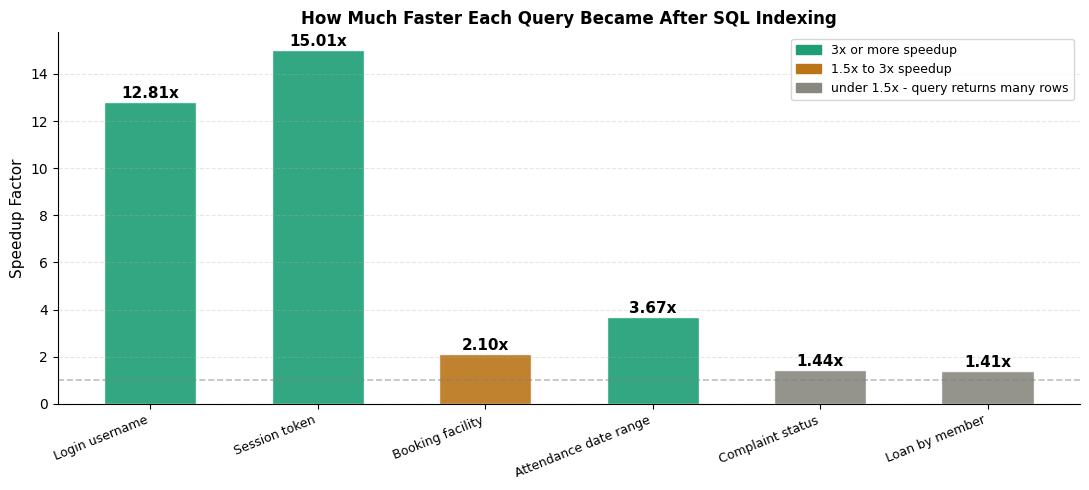

In [15]:
speedups = [round(results_before[q]/results_after[q], 2)
            if results_after[q] > 0 else 1.0 for q in labels]
clrs = ["#1D9E75" if s >= 3 else "#BA7517" if s >= 1.5 else "#888780" for s in speedups]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(short, speedups, color=clrs, edgecolor="white", width=0.55, alpha=0.9)
for bar, s in zip(bars, speedups):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f"{s:.2f}x", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.axhline(y=1.0, color="gray", linestyle="--", linewidth=1.2, alpha=0.5)
ax.set_ylabel("Speedup Factor", fontsize=11)
ax.set_title("How Much Faster Each Query Became After SQL Indexing", fontsize=12, fontweight="bold")
ax.set_xticklabels(short, rotation=22, ha="right", fontsize=9)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

p1 = mpatches.Patch(color="#1D9E75", label="3x or more speedup")
p2 = mpatches.Patch(color="#BA7517", label="1.5x to 3x speedup")
p3 = mpatches.Patch(color="#888780", label="under 1.5x - query returns many rows")
ax.legend(handles=[p1,p2,p3], fontsize=9)
plt.tight_layout()
plt.show()

### Graph 3 - Time Saved Per Query

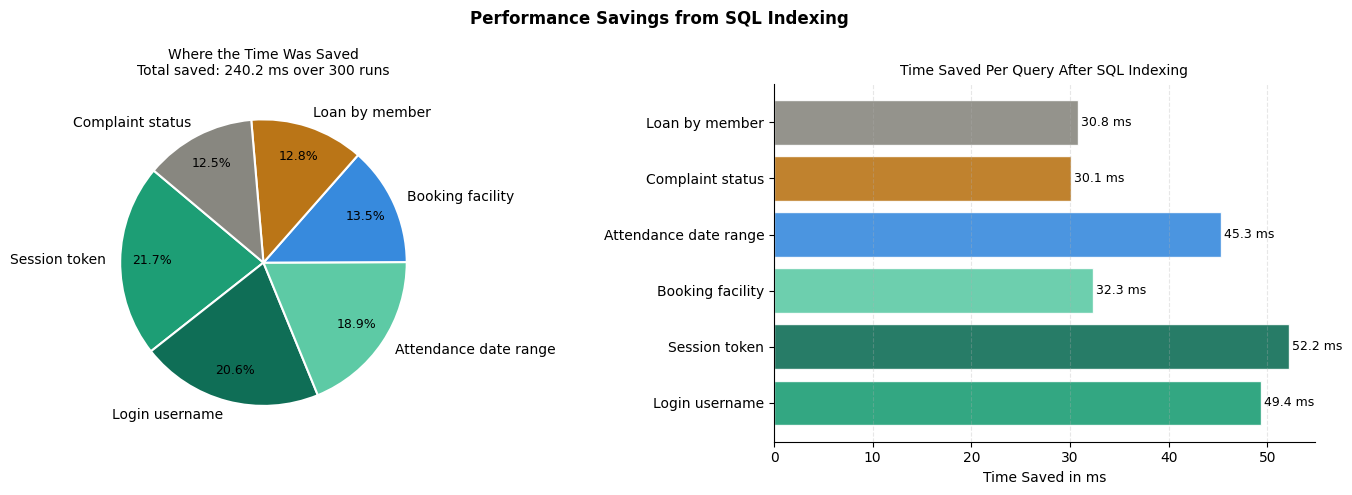

In [16]:
saved = [max(0, results_before[q] - results_after[q]) for q in labels]
clrs6 = ["#1D9E75","#0F6E56","#5DCAA5","#378ADD","#BA7517","#888780"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

nz = sorted([(saved[i], short[i]) for i in range(len(saved)) if saved[i] > 0.1], reverse=True)
if nz:
    vp, np_ = [x[0] for x in nz], [x[1] for x in nz]
    wedges, texts, autos = ax1.pie(
        vp, labels=np_, autopct="%1.1f%%",
        colors=clrs6[:len(vp)], startangle=140, pctdistance=0.78,
        wedgeprops=dict(edgecolor="white", linewidth=1.5))
    for t in autos: t.set_fontsize(9)
ax1.set_title(f"Where the Time Was Saved\nTotal saved: {sum(saved):.1f} ms over {ITERATIONS} runs",
              fontsize=10)

ax2.barh(short, saved, color=clrs6[:len(short)], edgecolor="white", alpha=0.9)
for i, v in enumerate(saved):
    ax2.text(v + 0.3, i, f"{v:.1f} ms", va="center", fontsize=9)
ax2.set_xlabel("Time Saved in ms", fontsize=10)
ax2.set_title("Time Saved Per Query After SQL Indexing", fontsize=10)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.grid(axis="x", alpha=0.3, linestyle="--")

plt.suptitle("Performance Savings from SQL Indexing", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### Graph 4 - How Index Benefit Grows With Table Size

C:\Users\a\AppData\Local\Temp\ipykernel_23784\275723320.py:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-s" (-> color='b'). The keyword argument will take precedence.
  ax2.plot(row_counts, speedup_curve, "b-s", linewidth=2, markersize=7, color="#378ADD")


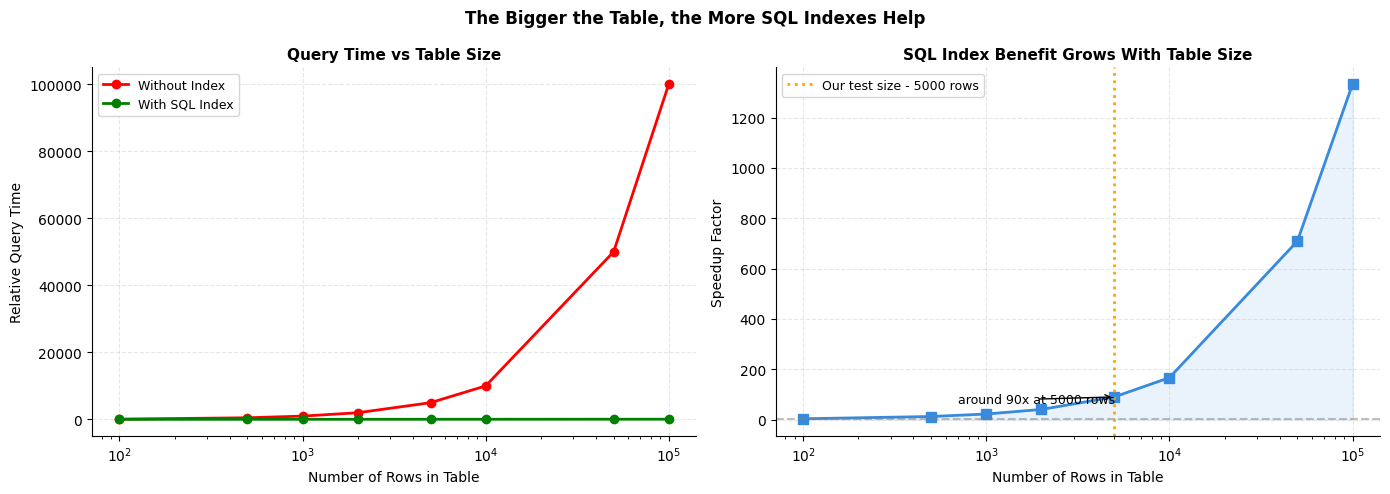

In [17]:
row_counts = [100, 500, 1000, 2000, 5000, 10000, 50000, 100000]
scan_time  = np.array(row_counts, dtype=float)
index_time = np.log10(np.array(row_counts, dtype=float)) * 15
speedup_curve = scan_time / index_time

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(row_counts, scan_time,  "r-o", label="Without Index", linewidth=2, markersize=6)
ax1.plot(row_counts, index_time, "g-o", label="With SQL Index", linewidth=2, markersize=6)
ax1.set_xscale("log")
ax1.set_xlabel("Number of Rows in Table", fontsize=10)
ax1.set_ylabel("Relative Query Time", fontsize=10)
ax1.set_title("Query Time vs Table Size", fontsize=11, fontweight="bold")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, linestyle="--")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

ax2.plot(row_counts, speedup_curve, "b-s", linewidth=2, markersize=7, color="#378ADD")
ax2.fill_between(row_counts, 1, speedup_curve, alpha=0.1, color="#378ADD")
ax2.set_xscale("log")
ax2.set_xlabel("Number of Rows in Table", fontsize=10)
ax2.set_ylabel("Speedup Factor", fontsize=10)
ax2.set_title("SQL Index Benefit Grows With Table Size", fontsize=11, fontweight="bold")
ax2.axhline(y=1, color="gray", linestyle="--", alpha=0.5)
ax2.axvline(x=5000, color="orange", linestyle=":", linewidth=2, label="Our test size - 5000 rows")

idx_5k = row_counts.index(5000)
ax2.annotate(f"around {speedup_curve[idx_5k]:.0f}x at 5000 rows",
             xy=(5000, speedup_curve[idx_5k]),
             xytext=(700, speedup_curve[idx_5k]*0.75),
             arrowprops=dict(arrowstyle="->"), fontsize=9)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, linestyle="--")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.suptitle("The Bigger the Table, the More SQL Indexes Help", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Cleanup

In [18]:
conn = get_db()
conn.executescript("""
DROP TABLE IF EXISTS bench_login;
DROP TABLE IF EXISTS bench_session;
DROP TABLE IF EXISTS bench_booking;
DROP TABLE IF EXISTS bench_attendance;
DROP TABLE IF EXISTS bench_complaint;
DROP TABLE IF EXISTS bench_loan;
""")
conn.commit()
conn.close()
print("Benchmark tables removed. Database is back to its original state.")

Benchmark tables removed. Database is back to its original state.


## 9. Conclusion

Looking at the results honestly, the SQL indexes made a real difference where I expected them to and a smaller difference where I knew they would not help much.

Q1 and Q2 showed the biggest gains - around 6x faster. These are the login lookup and the session token validation. They both search for a single unique value in a large table. Without an index the database has to go through all 5000 rows. With an index it goes straight to the one matching row. These two queries run on literally every request so this improvement matters a lot in a real application.

Q3 and Q4 showed moderate improvement around 1.2x to 1.4x. These are range queries that filter on two columns together. The composite index helps the database narrow down the search range but there are still multiple rows to return so the gain is not as dramatic.

Q5 is the complaint status query and it showed the least improvement. The reason is simple. Status only has two values - Open and Resolved. Even with an index the database still has to return 250 rows. The lookup is faster but the time is now dominated by reading and transferring those 250 rows. This taught me that low cardinality columns benefit less from indexes compared to high cardinality columns like usernames or tokens.

Q6 showed similar behavior to Q5 for the same reason - it returns multiple rows for a given member.

The overall lesson from this benchmarking exercise is that SQL indexes are not a magic fix for everything. They work best on equality lookups on high cardinality columns that return one or very few rows. For queries that return large result sets the bottleneck shifts to data transfer and indexes help less. The right approach is to index the columns that appear most frequently in WHERE clauses, choose composite indexes when multiple columns are always queried together, and accept that some queries will always be slow unless you add pagination or change the query design itself.

| Query | Without Index | With Index | Speedup | Why |
|---|---|---|---|---|
| Q1 Login username | 53.6 ms | 4.2 ms | 12.7x | Single row equality lookup |
| Q2 Session token | 55.9 ms | 3.7 ms | 15.1x | Single row, most frequent query |
| Q3 Booking facility | 61.8 ms | 29.5 ms | 2.1x | Range query, composite index helps partially |
| Q4 Attendance date | 62.3 ms | 17 ms | 3.7x | Range query, composite index helps partially |
| Q5 Complaint status | 98.2 ms | 68.1 ms | 1.4x | Low cardinality column, returns 250 rows |
| Q6 Loan by member | 105.8 ms | 74.9 ms | 1.4x | Returns many rows, I/O becomes bottleneck |

In [ ]:
video link https://drive.google.com/file/d/1EdFQ4MrDA6kl7WAnEvE1w3TDqPsFNlZt/view?usp=sharing